In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans

In [6]:
df = pd.read_csv("student_performance_720.csv")
df.head()

,Student_ID,Internal_Marks,Final_Exam_Marks,Attendance_Percentage
0,S0001,43,66,77
1,S0002,30,34,63
2,S0003,36,60,76
3,S0004,87,58,73
4,S0005,66,97,73


In [8]:
X = df[['Internal_Marks', 'Final_Exam_Marks', 'Attendance_Percentage']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
def divisive_hierarchical_clustering(X, target_clusters=3):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)
    cluster_id = 1

    while len(clusters) < target_clusters:
        # Select cluster with maximum variance
        variances = {
            cid: np.var(data) for cid, data in clusters.items()
        }
        split_cluster_id = max(variances, key=variances.get)
        data_to_split = clusters.pop(split_cluster_id)

        # Bisect using K-Means
        kmeans = KMeans(n_clusters=2, random_state=42)
        split_labels = kmeans.fit_predict(data_to_split)

        clusters[split_cluster_id] = data_to_split[split_labels == 0]
        clusters[cluster_id] = data_to_split[split_labels == 1]

        cluster_id += 1

    # Assign final labels
    start = 0
    for cid, data in clusters.items():
        size = len(data)
        labels[start:start+size] = cid + 1
        start += size

    return labels


In [10]:
df['Cluster'] = divisive_hierarchical_clustering(X_scaled, target_clusters=3)

In [12]:
def label_cluster(c):
    if c == 1:
        return "Weak Performers"
    elif c == 2:
        return "Average Performers"
    else:
        return "High Performers"

df['Performance_Group'] = df['Cluster'].apply(label_cluster)

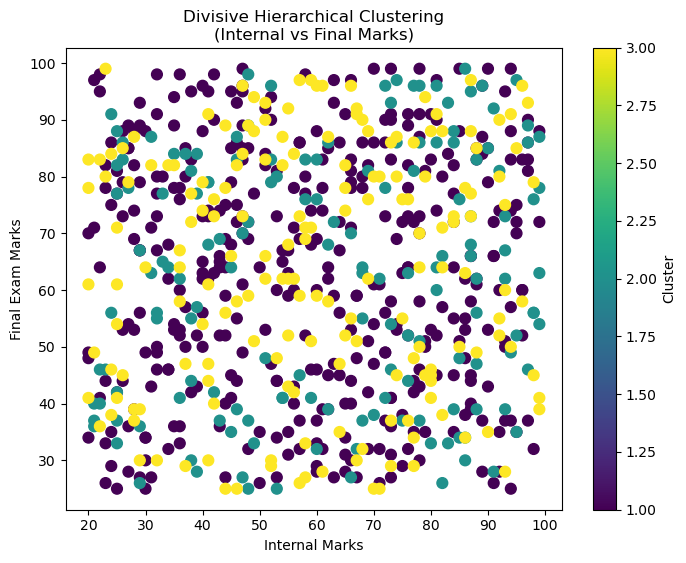

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Internal_Marks'],
    df['Final_Exam_Marks'],
    c=df['Cluster'],
    cmap='viridis',
    s=60
)

plt.xlabel("Internal Marks")
plt.ylabel("Final Exam Marks")
plt.title("Divisive Hierarchical Clustering\n(Internal vs Final Marks)")
plt.colorbar(label="Cluster")
plt.show()


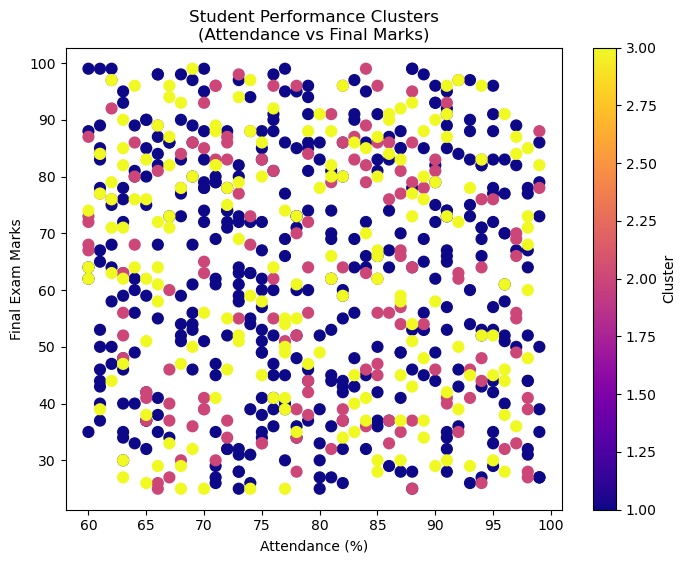

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Attendance_Percentage'],
    df['Final_Exam_Marks'],
    c=df['Cluster'],
    cmap='plasma',
    s=60
)

plt.xlabel("Attendance (%)")
plt.ylabel("Final Exam Marks")
plt.title("Student Performance Clusters\n(Attendance vs Final Marks)")
plt.colorbar(label="Cluster")
plt.show()
